# 1000 Genomes VCF Normalization and Population Analysis

## Colab Notebook Documentation (Future Reference)

---

## 📋 Purpose of This Notebook

This notebook implements a complete preprocessing and analysis pipeline for chromosome-level **1000 Genomes Project (GRCh38)** VCF files.

### The pipeline is designed to:

- Standardize chromosome naming (for example, `1` → `chr1`)
- Normalize variants using the hg38 reference genome
- Split multi-allelic variants into bi-allelic records
- Validate normalization correctness
- Convert VCF data into pandas DataFrames
- Analyze population-specific allele frequencies
- Generate plots for population comparison and bias inspection

**This preprocessing step is mandatory before downstream statistical analysis or machine learning.**

---

## 🔧 Environment Setup
```python
!pip install cyvcf2 --quiet
!apt-get update
!apt-get install -y bcftools tabix
```

### Why This Is Required

#### cyvcf2
Provides fast iteration over large VCF files using htslib bindings.

#### bcftools
Core tool for renaming chromosomes, normalization, filtering, compression, and indexing.

#### tabix
Enables indexing and fast access to compressed VCF files (.vcf.gz).

---

## 📂 Google Drive Mounting
```python
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
```

This allows persistent access to raw genomic data and storage of processed outputs.

---

## 📦 Python Imports
```python
import subprocess
import os
import pandas as pd
from cyvcf2 import VCF
from pathlib import Path
```

### Role of Each Import

#### `subprocess`
Executes bcftools and tabix commands from within Python.

#### `os / Path`
Directory management, file existence checks, and cleanup.

#### `pandas`
Used for tabular representation of variant-level data.

#### `cyvcf2.VCF`
Efficient streaming access to VCF records.

---

## 🏗️ Pipeline Design Principles

This pipeline follows these principles:

1. Enforce a single, canonical variant representation
2. Fail loudly rather than silently
3. Separate biological correctness from downstream modeling
4. Ensure reproducibility and auditability

---

## 🔄 Step 1: Chromosome Name Standardization

### Function: `add_chr_prefix`

Some datasets label chromosomes as `1`, while others use `chr1`. This mismatch causes failures during normalization and dataset merging.

### This step:

- Creates a temporary chromosome rename map
- Uses `bcftools annotate --rename-chrs`
- Renames chromosome labels only
- Does not modify positions or alleles

**This ensures compatibility with hg38-based tools.**

---

## 🗂️ Step 2: Indexing VCF Files

### Function: `index_vcf`

Each compressed VCF file is indexed using:
```bash
tabix -p vcf
```

### Indexing is required to:

- Enable region-based queries
- Allow efficient iteration
- Support downstream bcftools and cyvcf2 operations

**The pipeline verifies index creation before proceeding.**

---

## ⚗️ Step 3: Variant Normalization

### Function: `normalize_vcf`

Normalization ensures that each variant is represented in a canonical form.
```bash
bcftools norm \
  -m- \
  -f hg38.fa \
  --check-ref w
```

### What This Step Does

- Splits multi-allelic variants into separate bi-allelic records
- Left-aligns indels
- Validates reference alleles against hg38
- Warns about mismatches without stopping execution

### This step is critical for:

- Correct protein mapping
- Reliable allele frequency interpretation
- Machine learning compatibility

---

## ✅ Step 4: Normalization Verification

### Function: `verify_normalization`

This step performs a sampling-based validation using cyvcf2.

### It checks:

- Only one alternate allele per variant
- Correct chromosome naming
- Absence of residual multi-allelic records

**This acts as a safety check against silent data corruption.**

---

## 🧹 Step 5: Temporary File Cleanup

### Function: `cleanup_temp_files`

Intermediate files created during renaming and normalization are deleted to:

- Reduce storage usage
- Prevent accidental reuse
- Keep project directories clean

---

## 🔁 Main Normalization Pipeline

### Function: `normalize_chromosome_pipeline`

This function coordinates the full normalization workflow:

1. Create output and temporary directories
2. Rename chromosome labels
3. Index renamed VCF
4. Normalize variants
5. Index normalized VCF
6. Verify normalization
7. Remove temporary files
8. Print final summary

**The pipeline is chromosome-specific and reusable.**

---

## 📊 Extracting VCF Data to a DataFrame

### Function: `extract_vcf_to_dataframe`

This function converts a normalized VCF into a pandas DataFrame.

### Extracted fields include:

- Chromosome
- Position
- Reference allele
- Alternate allele
- Global allele frequency (AF)
- **Population-specific allele frequencies:**
  - SAS_AF
  - EUR_AF
  - AFR_AF
  - AMR_AF
  - EAS_AF
- Allele count (AC)
- Allele number (AN)

**Progress is logged periodically for long runs.**

---

## 💾 Saving Extracted Data

### Function: `save_dataframe`

The DataFrame is saved as a CSV file.

### This format is chosen because it is:

- Easy to inspect
- Compatible with ML workflows
- Portable across environments

---

## 🔄 Complete Extraction Pipeline

### Function: `extract_chromosome_pipeline`

This function:

1. Extracts variants into a DataFrame
2. Saves the CSV file
3. Reports population coverage statistics
4. Prints a completion summary

**Each chromosome produces one normalized VCF and one analysis-ready CSV.**

---

## 📈 Population Frequency Analysis

### Rare Variant Distribution

Histograms are generated for allele frequencies below 5% to:

- Compare populations
- Inspect rare variant burden
- Validate frequency extraction

**A logarithmic y-axis is used due to skewed distributions.**

### Variant Presence Across Populations

A bar plot summarizes:

- Number of variants with allele frequency > 0
- Per population group

**This supports population bias and representation analysis.**

---

## 🌏 Optional: South Asian Sample Filtering

### Function: `filter_south_asian_samples`

This optional step filters genotypes, not just frequencies.

### It:

- Uses a predefined list of South Asian sample IDs
- Retains only SAS individuals
- Produces a SAS-only VCF

**This must be run before normalization if genotype-level analysis is required.**

---

## 📦 Final Outputs

After running the notebook, the outputs include:

- Normalized and indexed chromosome-level VCFs
- CSV files with population allele frequencies
- Population distribution plots
- Variant density visualizations

### All outputs are:

✅ GRCh38 consistent  
✅ Population aware  
✅ Machine learning safe  
✅ Reproducible

---

In [ ]:
!pip install cyvcf2 --quiet

!apt-get update
!apt-get install -y bcftools tabix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 2.5 MB/s eta 0:00:00
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 ht

In [ ]:
!rm -rf /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
ls -lh /content/drive/MyDrive/FYP_DATA/raw_data/

total 28K
drwx------ 2 root root 4.0K Dec  8 16:52 1000genomes/
drwx------ 2 root root 4.0K Nov 28 21:46 1000_genomes_project_grch38/
drwx------ 2 root root 4.0K Oct 13 18:07 ClinVar/
drwx------ 2 root root 4.0K Nov 17 19:50 DOCUMENTATION/
drwx------ 2 root root 4.0K Oct 13 11:53 gnomad_data/
drwx------ 2 root root 4.0K Oct 22 13:18 IndiGen/
drwx------ 2 root root 4.0K Oct 25 19:17 reference_fasta/


In [ ]:
import subprocess
import os
import pandas as pd
from cyvcf2 import VCF
from pathlib import Path

In [ ]:
# ============================================================
# NORMALIZATION FUNCTIONS
# ============================================================

def add_chr_prefix(input_vcf, output_vcf, chrom_number, temp_dir='/tmp'):

    print("\n" + "=" * 70)
    print(f"STEP 1: Adding 'chr' prefix to chromosome {chrom_number}")
    print("=" * 70)

    # Create chromosome rename file
    chr_rename_file = f'{temp_dir}/chr{chrom_number}_rename.txt'
    with open(chr_rename_file, 'w') as f:
        f.write(f"{chrom_number} chr{chrom_number}\n")

    print(f"📝 Renaming: {chrom_number} → chr{chrom_number}")

    rename_cmd = f"""
    bcftools annotate \
        --rename-chrs {chr_rename_file} \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print("⏱️  Renaming chromosome...")
    result = subprocess.run(
        rename_cmd,
        shell=True,
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print("\n❌ CHROMOSOME RENAMING FAILED!")
        print(result.stderr)
        raise Exception("Chromosome renaming failed")

    print(f"✓ Chromosome renamed to chr{chrom_number}")

    # Cleanup rename file
    if os.path.exists(chr_rename_file):
        os.remove(chr_rename_file)

    return output_vcf


def index_vcf(vcf_file):

    print(f"📑 Creating index for {os.path.basename(vcf_file)}...")

    index_result = subprocess.run(
        f"tabix -f -p vcf {vcf_file}",
        shell=True,
        capture_output=True,
        text=True
    )

    if index_result.returncode != 0:
        print(f"❌ Indexing failed!")
        print(f"Error: {index_result.stderr}")
        raise Exception("Failed to create index")

    # Verify index exists
    if os.path.exists(f"{vcf_file}.tbi"):
        index_size = os.path.getsize(f"{vcf_file}.tbi") / 1024
        print(f"✓ Index created ({index_size:.1f} KB)")
        return True
    else:
        print("❌ Index file not found!")
        raise Exception("Failed to create index")


def normalize_vcf(input_vcf, output_vcf, reference_fasta):


    print("\n" + "=" * 70)
    print("STEP 2: Normalizing VCF")
    print("=" * 70)

    norm_cmd = f"""
    bcftools norm \
        -m- \
        -f {reference_fasta} \
        --check-ref w \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print("⏱️  Normalizing VCF (splitting multi-allelic, left-aligning)...")
    result = subprocess.run(
        norm_cmd,
        shell=True,
        capture_output=True,
        text=True
    )

    # Print normalization stats
    if result.stderr:
        print("\n📊 Normalization Stats:")
        print(result.stderr)

    if result.returncode != 0:
        print("\n❌ NORMALIZATION FAILED!")
        print(result.stdout)
        print(result.stderr)
        raise Exception("Normalization failed")

    print(f"\n✓ Normalized VCF created successfully!")

    return output_vcf


def verify_normalization(vcf_file, sample_size=10000):

    print("\n" + "=" * 70)
    print("STEP 3: Verifying normalization")
    print("=" * 70)

    vcf = VCF(vcf_file)

    chromosomes_found = set()
    multi_count = 0
    total = 0

    print(f"\nScanning up to {sample_size:,} variants...")

    for variant in vcf:
        chromosomes_found.add(variant.CHROM)
        if len(variant.ALT) > 1:
            multi_count += 1
        total += 1

        if total >= sample_size:
            break

    print(f"\n✓ Verification Results:")
    print(f"   Total variants checked: {total:,}")
    print(f"   Chromosomes found: {sorted(chromosomes_found)}")
    print(f"   Multi-allelic variants: {multi_count}")

    if multi_count == 0:
        print("   ✓ All sampled variants are properly split!")
    else:
        print(f"   ⚠️  Found {multi_count} multi-allelic variants in sample")

    return {
        'total_checked': total,
        'chromosomes': list(chromosomes_found),
        'multi_allelic_count': multi_count
    }


def cleanup_temp_files(file_list):


    cleaned_count = 0
    for temp_file in file_list:
        if os.path.exists(temp_file):
            try:
                os.remove(temp_file)
                cleaned_count += 1
                print(f"   Removed: {os.path.basename(temp_file)}")
            except Exception as e:
                print(f"   Could not remove {os.path.basename(temp_file)}: {e}")

    print(f"\n✓ Cleaned up {cleaned_count} temporary files")

    return cleaned_count



In [ ]:

# ============================================================
# MAIN NORMALIZATION PIPELINE
# ============================================================

def normalize_chromosome_pipeline(input_vcf, output_vcf, reference_fasta,
                                  chrom_number, output_dir, temp_dir='/tmp'):


    print("\n" + "=" * 80)
    print(f"1000 GENOMES NORMALIZATION PIPELINE - CHROMOSOME {chrom_number}")
    print("=" * 80)

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(temp_dir, exist_ok=True)

    # Define temporary file paths
    temp_chr_renamed = f'{temp_dir}/1k_chr{chrom_number}_renamed.vcf.gz'

    # Step 1: Add chr prefix
    add_chr_prefix(input_vcf, temp_chr_renamed, chrom_number, temp_dir)

    # Index renamed file
    index_vcf(temp_chr_renamed)

    # Step 2: Normalize
    normalize_vcf(temp_chr_renamed, output_vcf, reference_fasta)

    # Index normalized file
    index_vcf(output_vcf)

    # Step 3: Verify
    verify_normalization(output_vcf)

    # Step 4: Cleanup
    cleanup_temp_files([
        temp_chr_renamed,
        f'{temp_chr_renamed}.tbi'
    ])

    # Final summary
    print("\n" + "=" * 80)
    print(f"✅ CHROMOSOME {chrom_number} NORMALIZATION COMPLETE!")
    print("=" * 80)
    print(f"\n📂 Output file:")
    print(f"   {output_vcf}")
    print(f"\n📂 Index file:")
    print(f"   {output_vcf}.tbi")

    output_size = os.path.getsize(output_vcf) / (1024 * 1024)
    print(f"\n📊 File size: {output_size:.1f} MB")
    print("=" * 80)

    return output_vcf



In [ ]:

# ============================================================
# VCF EXTRACTION FUNCTIONS
# ============================================================

def extract_vcf_to_dataframe(vcf_path, chrom_number=None):
    """
    Extract 1000 Genomes VCF to pandas DataFrame

    Args:
        vcf_path: path to normalized VCF file
        chrom_number: chromosome number for progress labeling (optional)

    Returns:
        pandas DataFrame with variant information
    """

    print("\n" + "=" * 70)
    print(f"EXTRACTING VCF TO DATAFRAME - CHROMOSOME {chrom_number}")
    print("=" * 70)
    print(f"📥 Input: {vcf_path}")

    variants = []
    count = 0

    vcf = VCF(vcf_path)

    print("\n⏱️  Extracting variant data...")

    for variant in vcf:
        # Basic variant info
        chrom = variant.CHROM
        pos = variant.POS
        ref = variant.REF
        alt = variant.ALT[0] if variant.ALT else None

        # Extract allele frequency fields from INFO
        af = variant.INFO.get('AF', None)

        # Population-specific allele frequencies
        sas_af = variant.INFO.get('SAS_AF', None)
        eur_af = variant.INFO.get('EUR_AF', None)
        afr_af = variant.INFO.get('AFR_AF', None)
        amr_af = variant.INFO.get('AMR_AF', None)
        eas_af = variant.INFO.get('EAS_AF', None)

        # Additional INFO fields
        ac = variant.INFO.get('AC', None)
        an = variant.INFO.get('AN', None)

        # Store in list
        variants.append({
            'CHROM': chrom,
            'POS': pos,
            'REF': ref,
            'ALT': alt,
            'AF': af,
            'SAS_AF': sas_af,
            'EUR_AF': eur_af,
            'AFR_AF': afr_af,
            'AMR_AF': amr_af,
            'EAS_AF': eas_af,
            'AC': ac,
            'AN': an
        })

        count += 1
        if count % 50000 == 0:
            print(f"   {count:,} variants extracted...")

    # Convert to DataFrame
    df = pd.DataFrame(variants)

    print(f"\n✓ Extraction complete!")
    print(f"   Total variants: {len(df):,}")
    print(f"   Columns: {list(df.columns)}")

    return df


def save_dataframe(df, output_path, chrom_number=None):
    """
    Save DataFrame to CSV file

    Args:
        df: pandas DataFrame
        output_path: path to output CSV file
        chrom_number: chromosome number for labeling (optional)

    Returns:
        output_path
    """

    print(f"\n💾 Saving DataFrame to CSV...")

    df.to_csv(output_path, index=False)

    file_size = os.path.getsize(output_path) / (1024 * 1024)

    print(f"✓ Saved to: {output_path}")
    print(f"   File size: {file_size:.1f} MB")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    return output_path



In [ ]:

# ============================================================
# COMPLETE EXTRACTION PIPELINE
# ============================================================

def extract_chromosome_pipeline(vcf_path, output_csv, chrom_number):
    """
    Complete extraction pipeline for a single chromosome

    Args:
        vcf_path: path to normalized VCF file
        output_csv: path to output CSV file
        chrom_number: chromosome number

    Returns:
        pandas DataFrame
    """

    print("\n" + "=" * 80)
    print(f"1000 GENOMES EXTRACTION PIPELINE - CHROMOSOME {chrom_number}")
    print("=" * 80)

    # Extract VCF to DataFrame
    df = extract_vcf_to_dataframe(vcf_path, chrom_number)

    # Save to CSV
    save_dataframe(df, output_csv, chrom_number)

    # Summary statistics
    print("\n" + "=" * 80)
    print(f"✅ CHROMOSOME {chrom_number} EXTRACTION COMPLETE!")
    print("=" * 80)

    print("\n📊 Summary Statistics:")
    print(f"   Total variants: {len(df):,}")

    # Count non-null values for each frequency column
    for col in ['AF', 'SAS_AF', 'EUR_AF', 'AFR_AF', 'AMR_AF', 'EAS_AF']:
        if col in df.columns:
            non_null = df[col].notna().sum()
            print(f"   {col} available: {non_null:,} ({non_null/len(df)*100:.1f}%)")

    print("\n📂 Output files:")
    print(f"   CSV: {output_csv}")
    print("=" * 80)

    return df



In [ ]:
reference_fasta = '/content/drive/MyDrive/FYP_DATA/raw_data/reference_fasta/hg38_dna.fa'
input_vcf = '/content/drive/MyDrive/FYP_DATA/raw_data/1000_genomes_project_grch38/chr1.vcf.gz'
output_dir = '/content/drive/MyDrive/FYP_DATA/processed_data/1k'
output_vcf = f'{output_dir}/1k_chr1_normalized.vcf.gz'

In [ ]:
normalized_vcf = normalize_chromosome_pipeline(
    input_vcf=input_vcf,
    output_vcf=output_vcf,
    reference_fasta=reference_fasta,
    chrom_number=1,
    output_dir=output_dir,
    temp_dir='/tmp'
)


1000 GENOMES NORMALIZATION PIPELINE - CHROMOSOME 1

STEP 1: Adding 'chr' prefix to chromosome 1
📝 Renaming: 1 → chr1
⏱️  Renaming chromosome...
✓ Chromosome renamed to chr1
📑 Creating index for 1k_chr1_renamed.vcf.gz...
✓ Index created (207.6 KB)

STEP 2: Normalizing VCF
⏱️  Normalizing VCF (splitting multi-allelic, left-aligning)...

📊 Normalization Stats:
Lines   total/split/realigned/skipped:	6191833/0/0/0


✓ Normalized VCF created successfully!
📑 Creating index for 1k_chr1_normalized.vcf.gz...
✓ Index created (207.6 KB)

STEP 3: Verifying normalization

Scanning up to 10,000 variants...

✓ Verification Results:
   Total variants checked: 10,000
   Chromosomes found: ['chr1']
   Multi-allelic variants: 0
   ✓ All sampled variants are properly split!
   Removed: 1k_chr1_renamed.vcf.gz
   Removed: 1k_chr1_renamed.vcf.gz.tbi

✓ Cleaned up 2 temporary files

✅ CHROMOSOME 1 NORMALIZATION COMPLETE!

📂 Output file:
   /content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_normalized.v

In [ ]:
# Example 2: Extract to DataFrame
output_csv = f'{output_dir}/1k_chr1_variants.csv'

df = extract_chromosome_pipeline(
    vcf_path=output_vcf,
    output_csv=output_csv,
    chrom_number=1
)

# Example 3: View the data
print(df.head())
print(df.info())


1000 GENOMES EXTRACTION PIPELINE - CHROMOSOME 1

EXTRACTING VCF TO DATAFRAME - CHROMOSOME 1
📥 Input: /content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_normalized.vcf.gz

⏱️  Extracting variant data...
   50,000 variants extracted...
   100,000 variants extracted...
   150,000 variants extracted...
   200,000 variants extracted...
   250,000 variants extracted...
   300,000 variants extracted...
   350,000 variants extracted...
   400,000 variants extracted...
   450,000 variants extracted...
   500,000 variants extracted...
   550,000 variants extracted...
   600,000 variants extracted...
   650,000 variants extracted...
   700,000 variants extracted...
   750,000 variants extracted...
   800,000 variants extracted...
   850,000 variants extracted...
   900,000 variants extracted...
   950,000 variants extracted...
   1,000,000 variants extracted...
   1,050,000 variants extracted...
   1,100,000 variants extracted...
   1,150,000 variants extracted...
   1,200,000 variants ex

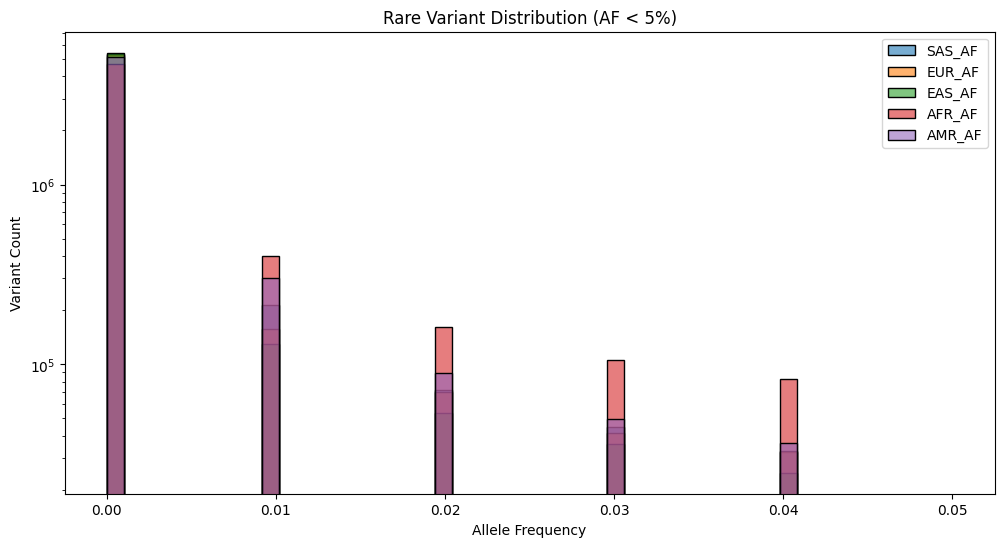

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load chr1 CSV
df = pd.read_csv('/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_variants.csv')

populations = ['SAS_AF', 'EUR_AF', 'EAS_AF','AFR_AF','AMR_AF']

plt.figure(figsize=(12, 6))
for pop in populations:
    sns.histplot(df[pop], bins=np.linspace(0,0.05,50), label=pop, alpha=0.6)
plt.title('Rare Variant Distribution (AF < 5%)')
plt.xlabel('Allele Frequency')
plt.ylabel('Variant Count')
plt.yscale('log')
plt.legend()
plt.show()


<Figure size 600x500 with 0 Axes>

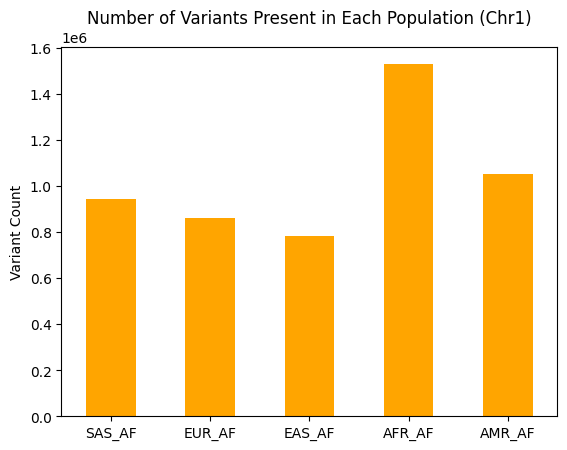

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load chr1 CSV
df = pd.read_csv('/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_variants.csv')

# Populations of interest
populations = ['SAS_AF', 'EUR_AF', 'EAS_AF','AFR_AF','AMR_AF']

# Count number of variants per population (AF > 0)
variant_counts = {}
for pop in populations:
    variant_counts[pop] = (df[pop] > 0).sum()

# Convert to DataFrame for plotting
variant_counts_df = pd.DataFrame.from_dict(variant_counts, orient='index', columns=['Variant Count'])

# Plot
plt.figure(figsize=(6,5))
variant_counts_df.plot(kind='bar', legend=False, color=['orange','skyblue','green'])
plt.title('Number of Variants Present in Each Population (Chr1)')
plt.ylabel('Variant Count')
plt.xticks(rotation=0)
plt.show()


In [ ]:

# ============================================================
# EXAMPLE USAGE
# ============================================================

"""
# Example 1: Normalize a single chromosome
reference_fasta = '/content/drive/MyDrive/FYP_DATA/raw_data/reference_fasta/hg38_dna.fa'
input_vcf = '/content/drive/MyDrive/FYP_DATA/raw_data/1000_genomes_project_grch38/chr1.vcf.gz'
output_dir = '/content/drive/MyDrive/FYP_DATA/processed_data/1k'
output_vcf = f'{output_dir}/1k_chr1_normalized.vcf.gz'

# Run normalization pipeline
normalized_vcf = normalize_chromosome_pipeline(
    input_vcf=input_vcf,
    output_vcf=output_vcf,
    reference_fasta=reference_fasta,
    chrom_number=1,
    output_dir=output_dir,
    temp_dir='/tmp'
)

# Example 2: Extract to DataFrame
output_csv = f'{output_dir}/1k_chr1_variants.csv'

df = extract_chromosome_pipeline(
    vcf_path=output_vcf,
    output_csv=output_csv,
    chrom_number=1
)

# Example 3: View the data
print(df.head())
print(df.info())

# Example 4: Filter for South Asian samples (BEFORE normalization)
sas_input = '/content/drive/MyDrive/FYP_DATA/raw_data/1000_genomes_project_grch38/chr1.vcf.gz'
sas_output = '/content/drive/MyDrive/FYP_DATA/raw_data/1000_genomes_project_grch38/chr1_SAS.vcf.gz'
sas_samples = '/content/drive/MyDrive/FYP_DATA/SAS_samples.txt'

filter_south_asian_samples(
    input_vcf=sas_input,
    output_vcf=sas_output,
    sas_samples_file=sas_samples
)


In [ ]:
# Paths
panel_file = '/content/drive/MyDrive/FYP_DATA/raw_data/1000genomes/1k_sas.txt'
sas_output_file = '/content/drive/MyDrive/FYP_DATA/raw_data/1000genomes/1k_sas_filtered.txt'

with open(panel_file, 'r') as f_in, open(sas_output_file, 'w') as f_out:
    for line in f_in:
        parts = line.strip().split()  # split on any whitespace
        if len(parts) >= 3 and parts[2] == 'SAS':
            f_out.write(parts[0] + '\n')

print(f"✅ SAS sample IDs saved to: {sas_output_file}")


✅ SAS sample IDs saved to: /content/drive/MyDrive/FYP_DATA/raw_data/1000genomes/1k_sas_filtered.txt


In [ ]:
with open(sas_output_file, 'r') as f:
    line_count = sum(1 for _ in f)

print(f"📋 Number of SAS samples: {line_count}")

📋 Number of SAS samples: 489


In [ ]:

# ============================================================
# SOUTH ASIAN FILTERING (OPTIONAL - USE BEFORE NORMALIZATION)
# ============================================================

def filter_south_asian_samples(input_vcf, output_vcf, sas_samples_file):

    print("\n" + "=" * 70)
    print("FILTERING FOR SOUTH ASIAN SAMPLES")
    print("=" * 70)

    if not os.path.exists(sas_samples_file):
        print(f"❌ SAS samples file not found: {sas_samples_file}")
        print("\nPlease create the file by running:")
        print("wget ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel")
        print("awk '$3 == \"SAS\" {print $1}' integrated_call_samples_v3.20130502.ALL.panel > SAS_samples.txt")
        raise FileNotFoundError(f"SAS samples file not found")

    # Count samples
    with open(sas_samples_file, 'r') as f:
        sample_count = sum(1 for _ in f)

    print(f"\n📋 Found {sample_count} South Asian samples")

    # Filter VCF
    filter_cmd = f"""
    bcftools view \
        -S {sas_samples_file} \
        -O z \
        -o {output_vcf} \
        {input_vcf}
    """

    print(f"\n⏱️  Filtering VCF for South Asian samples...")
    result = subprocess.run(filter_cmd, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print("❌ Filtering failed!")
        print(result.stderr)
        raise Exception("South Asian sample filtering failed")

    print(f"✓ Filtered VCF created: {output_vcf}")

    # Index the filtered VCF
    index_vcf(output_vcf)

    print("\n" + "=" * 70)
    print("✅ SOUTH ASIAN FILTERING COMPLETE!")
    print("=" * 70)

    return output_vcf



In [ ]:
# Example 4: Filter for South Asian samples (BEFORE normalization)
sas_input = '/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_normalized.vcf.gz'
sas_output = '/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_SAS_normalized.vcf.gz'
sas_samples = '/content/drive/MyDrive/FYP_DATA/raw_data/1000genomes/1k_sas_filtered.txt'

filter_south_asian_samples(
    input_vcf=sas_input,
    output_vcf=sas_output,
    sas_samples_file=sas_samples
)


FILTERING FOR SOUTH ASIAN SAMPLES

📋 Found 489 South Asian samples

⏱️  Filtering VCF for South Asian samples...
✓ Filtered VCF created: /content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_SAS_normalized.vcf.gz
📑 Creating index for 1k_chr1_SAS_normalized.vcf.gz...
✓ Index created (185.4 KB)

✅ SOUTH ASIAN FILTERING COMPLETE!


'/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_SAS_normalized.vcf.gz'

In [ ]:
vcf_file = '/content/drive/MyDrive/FYP_DATA/processed_data/1k/1k_chr1_SAS_normalized.vcf.gz'

vcf = VCF(vcf_file)

# Parse variants into a DataFrame
records = []
for variant in vcf:
    records.append({
        'chrom': variant.CHROM,
        'pos': variant.POS,
        'ref': variant.REF,
        'alt': ','.join(variant.ALT),
        'id': variant.ID,
        'qual': variant.QUAL
    })

df = pd.DataFrame(records)
print(df.head())

  chrom    pos     ref alt    id  qual
0  chr1  10416  CCCTAA   C  None  None
1  chr1  16103       T   G  None  None
2  chr1  17496      AC   A  None  None
3  chr1  51479       T   A  None  None
4  chr1  51898       C   A  None  None


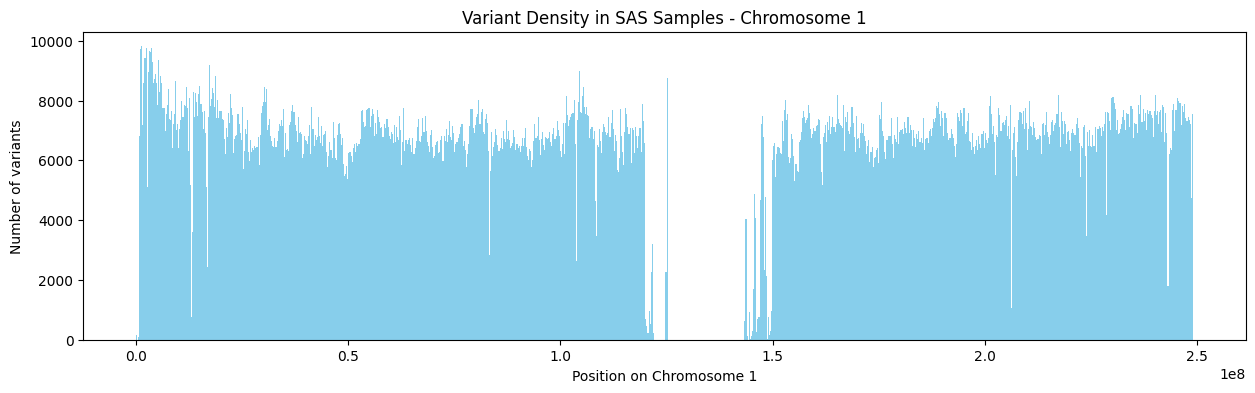

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.hist(df['pos'], bins=1000, color='skyblue')
plt.xlabel('Position on Chromosome 1')
plt.ylabel('Number of variants')
plt.title('Variant Density in SAS Samples - Chromosome 1')
plt.show()


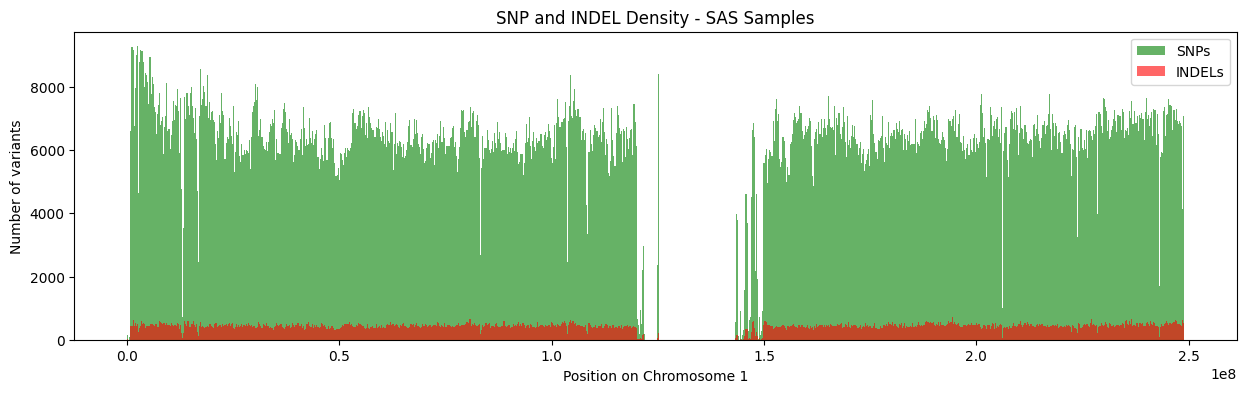

In [ ]:
df['type'] = df.apply(lambda row: 'SNP' if len(row['ref']) == 1 and len(row['alt']) == 1 else 'INDEL', axis=1)

# Separate positions
snps = df[df['type'] == 'SNP']['pos']
indels = df[df['type'] == 'INDEL']['pos']

plt.figure(figsize=(15,4))
plt.hist(snps, bins=1000, color='green', alpha=0.6, label='SNPs')
plt.hist(indels, bins=1000, color='red', alpha=0.6, label='INDELs')
plt.xlabel('Position on Chromosome 1')
plt.ylabel('Number of variants')
plt.title('SNP and INDEL Density - SAS Samples')
plt.legend()
plt.show()
